Question 2 part B Python code

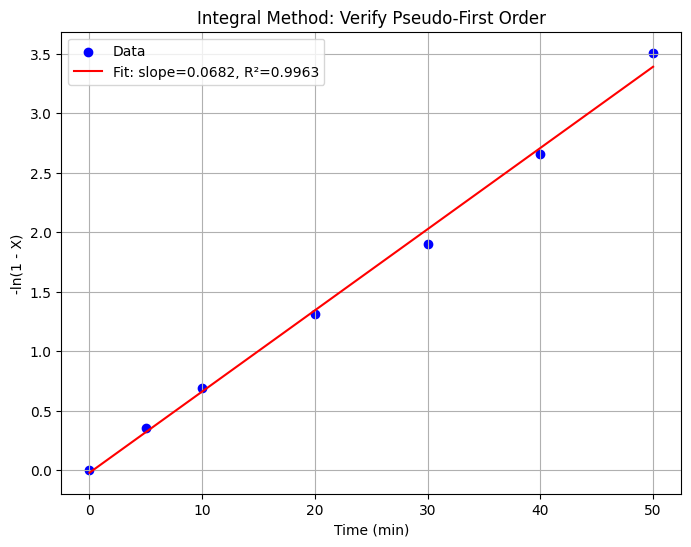

The plot is linear with R² = 0.9963


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Data
t = np.array([0, 5, 10, 20, 30, 40, 50])  # min
X = np.array([0.0, 0.30, 0.50, 0.73, 0.85, 0.93, 0.97])

# Calculate -ln(1-X)
one_minus_X = 1 - X
minus_ln = -np.log(one_minus_X)  # np.log is natural log

# Linear fit (exclude t=0 if needed, but include here)
slope, intercept, r_value, p_value, std_err = linregress(t, minus_ln)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(t, minus_ln, label='Data', color='blue')
plt.plot(t, slope*t + intercept, label=f'Fit: slope={slope:.4f}, R²={r_value**2:.4f}', color='red')
plt.xlabel('Time (min)')
plt.ylabel('-ln(1 - X)')
plt.title('Integral Method: Verify Pseudo-First Order')
plt.legend()
plt.grid(True)
plt.show()

# Markdown for final answer
print("The plot is linear with R² =", round(r_value**2, 4))

Question 2c

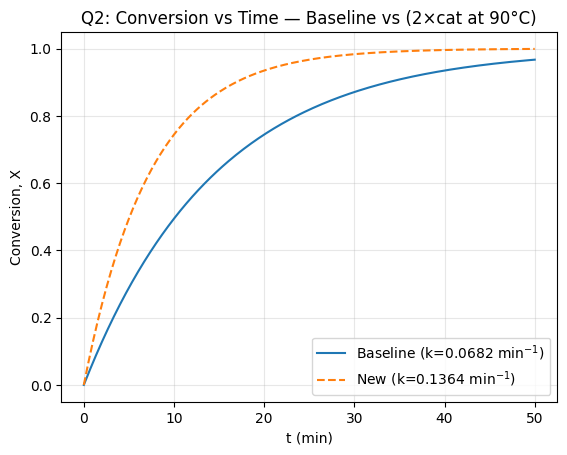

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from dataclasses import dataclass # Import dataclass

# "What if": Double catalyst and change temperature (Arrhenius scaling)
# You can toggle Arrhenius T-correction by setting Ea_Jmol (J/mol) or leaving it None.

@dataclass
class Q2Kinetics:
    k_ref_min1: float       # baseline apparent 1st-order k at T_ref (min^-1)
    T_ref_K: float          # K
    Ea_Jmol: float | None   # J/mol; if None, no T-correction
    cat_factor: float       # multiplicative change in catalyst amount
    T_new_K: float          # new temperature (K)

# R = 8.314 J/(mol·K) (Ideal gas constant)
R = 8.314

def arrhenius_scale(k_ref, T_ref, T_new, Ea):
    if Ea is None:
        return k_ref
    return k_ref * np.exp(-Ea/R * (1/T_new - 1/T_ref))

def k_effective(params: Q2Kinetics) -> float:
    k_T = arrhenius_scale(params.k_ref_min1, params.T_ref_K, params.T_new_K, params.Ea_Jmol)
    return k_T * params.cat_factor

# PARAMS (edit)
p2 = Q2Kinetics(
    k_ref_min1=0.0682,     # from your fit
    T_ref_K=373.15,        # 100 °C
    Ea_Jmol=None,          # put a number (e.g., 5.5e4) to include T-effect
    cat_factor=2.0,        # doubling catalyst
    T_new_K=363.15         # 90 °C
)

def X_first_order(t_min, k_min1):
    return 1 - np.exp(-k_min1 * t_min)

# Define t_min
t_min = np.array([0, 5, 10, 20, 30, 40, 50]) # min

t_dense = np.linspace(0, t_min.max(), 300)
X_base  = X_first_order(t_dense, p2.k_ref_min1)
X_new   = X_first_order(t_dense, k_effective(p2))

plt.figure()
plt.plot(t_dense, X_base, label=f'Baseline (k={p2.k_ref_min1:.4f} min$^{{-1}}$)')
plt.plot(t_dense, X_new,  '--', label=f'New (k={k_effective(p2):.4f} min$^{{-1}}$)')
plt.xlabel('t (min)'); plt.ylabel('Conversion, X')
plt.title('Q2: Conversion vs Time — Baseline vs (2×cat at 90°C)')
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

Question 3 Part b code

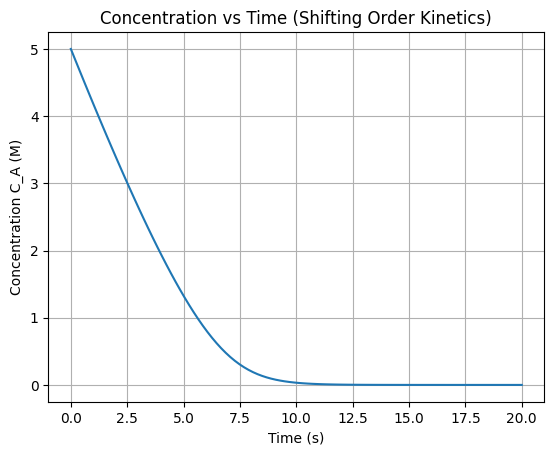

In [7]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Parameters (adjust units as needed; k in s^-1, K in M^-1, C0 in M)
k = 1.0
K = 1.0
C0 = 5.0

# ODE for dC/dt = -k C / (1 + K C)
def dCdt(C, t):
    return -k * C / (1 + K * C)

# Time array (adjust span for desired conversion; here up to ~90%+)
t = np.linspace(0, 20, 100)

# Solve ODE
C = odeint(dCdt, C0, t).flatten()

# Plot
plt.plot(t, C)
plt.xlabel('Time (s)')
plt.ylabel('Concentration C_A (M)')
plt.title('Concentration vs Time (Shifting Order Kinetics)')
plt.grid(True)
plt.show()

Question 3 part c

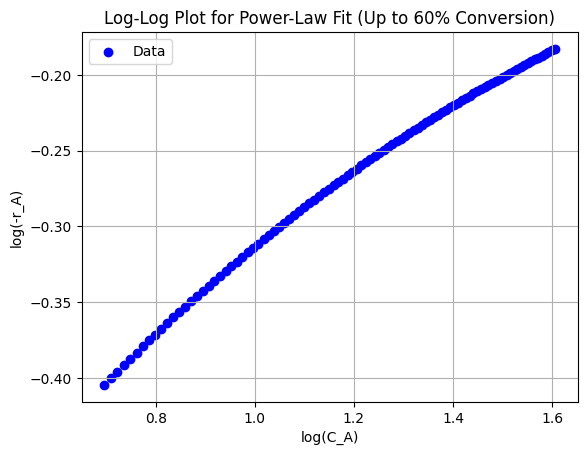

Apparent order alpha: 0.239
Apparent rate constant k': 0.574
R-squared: 0.992


In [6]:
import numpy as np
from scipy.integrate import odeint
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Parameters (same as above)
k = 1.0
K = 1.0
C0 = 5.0

# ODE function
def dCdt(C, t):
    return -k * C / (1 + K * C)

# Time array
t = np.linspace(0, 20, 500)  # More points for better derivative approx

# Solve ODE
C = odeint(dCdt, C0, t).flatten()

# Limit to 60% conversion (C <= 2.0 M)
idx = np.where(C <= 2.0)[0][0]
t_lim = t[:idx+1]
C_lim = C[:idx+1]

# Approximate -r_A = -dC/dt using finite differences
dC = np.diff(C_lim)
dt = np.diff(t_lim)
r_A_approx = -dC / dt  # Positive values

# Average C for each interval (midpoints)
C_avg = (C_lim[:-1] + C_lim[1:]) / 2

# Log values (discard any non-positive, but shouldn't happen)
log_r = np.log(r_A_approx)
log_C = np.log(C_avg)

# Plot
plt.scatter(log_C, log_r, color='blue', label='Data')
plt.xlabel('log(C_A)')
plt.ylabel('log(-r_A)')
plt.title('Log-Log Plot for Power-Law Fit (Up to 60% Conversion)')
plt.grid(True)
plt.legend()
plt.show()

# Linear fit (alpha = slope, log(k') = intercept)
slope, intercept, r_value, p_value, std_err = linregress(log_C, log_r)
print(f'Apparent order alpha: {slope:.3f}')
print(f'Apparent rate constant k\': {np.exp(intercept):.3f}')
print(f'R-squared: {r_value**2:.3f}')

Homework problem 4 part a

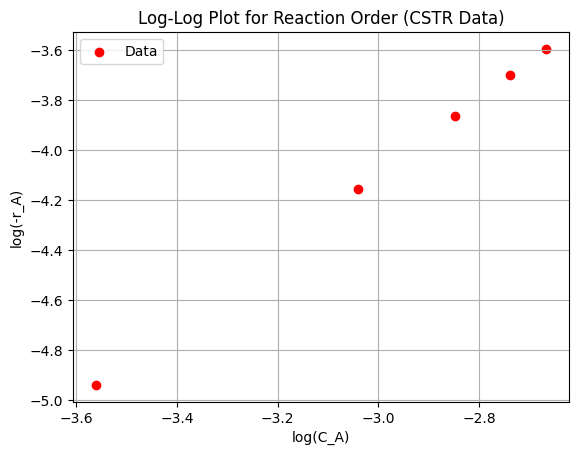

Reaction order alpha: 1.503
Rate constant k: 1.515 (units: (mol/L)^-0.503/s)
R-squared: 1.000


In [4]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Given data
v0 = np.array([1, 3, 5, 7, 9])  # Volumetric flow rate (L/s)
C_A_out = np.array([0.0284, 0.0478, 0.0580, 0.0647, 0.0695])  # mol/L
C_A0 = 0.1  # Initial concentration (mol/L)
V = 10.0  # Reactor volume (L)

# Space time tau = V / v0 (s)
tau = V / v0

# Rate -r_A = (C_A0 - C_A_out) / tau (mol/L/s)
r_A = (C_A0 - C_A_out) / tau  # Positive rate of disappearance

# Log values
log_r = np.log(r_A)
log_C = np.log(C_A_out)

# Plot
plt.scatter(log_C, log_r, color='red', label='Data')
plt.xlabel('log(C_A)')
plt.ylabel('log(-r_A)')
plt.title('Log-Log Plot for Reaction Order (CSTR Data)')
plt.grid(True)
plt.legend()
plt.show()

# Linear fit (alpha = slope, log(k) = intercept for -r_A = k C_A^alpha)
slope, intercept, r_value, p_value, std_err = linregress(log_C, log_r)
print(f'Reaction order alpha: {slope:.3f}')
print(f'Rate constant k: {np.exp(intercept):.3f} (units: (mol/L)^{1-slope:.3f}/s)')
print(f'R-squared: {r_value**2:.3f}')

Problem 6a

In [9]:
# Given
k1 = 15.0       # ft^3/(lb-mol·s)  (A→D)
k2 = 0.015      # 1/s              (A→U)
v  = 15.0       # ft^3/s
CA0 = 4.47e-3   # lb-mol/ft^3
FA0 = v * CA0

# C_A(V) from the analytical solution
def CA_of_V(V):
    L = (CA0 / (k1 * CA0 + k2)) * np.exp(-k2 * V / v)
    return (L * k2) / (1.0 - L * k1)

# Grid, rates, integrals
V = np.linspace(0.0, 5000.0, 20001)
dV = V[1] - V[0]
CA = CA_of_V(V)
FA = v * CA
r1 = k1 * CA**2
r2 = k2 * CA

FD = np.zeros_like(V)
FU = np.zeros_like(V)
for i in range(1, len(V)):
    FD[i] = FD[i-1] + r1[i-1] * dV
    FU[i] = FU[i-1] + r2[i-1] * dV

# Value function and optimum
profit = 60.0 * FD + 10.0 * FA - 15.0 * FU
imax = int(np.argmax(profit))
V_star = V[imax]
FA_star, FD_star, FU_star, profit_star = FA[imax], FD[imax], FU[imax], profit[imax]

print({"V* [ft^3]": V_star,
       "F_A*": FA_star, "F_D*": FD_star, "F_U*": FU_star,
       "Profit* [$ / s]": profit_star})

# Plots (one per figure; default colors; saved to HW3_Q6_Figures.pdf)


{'V* [ft^3]': np.float64(897.0), 'F_A*': np.float64(0.007496874278389577), 'F_D*': np.float64(0.04018085198457831), 'F_U*': np.float64(0.019416732576429303), 'Profit* [$ / s]': np.float64(2.194568873212155)}


Problem 6b

Max value at V = 100.00 ft³


/tmp/ipython-input-14778478.py:27: RuntimeWarning: invalid value encountered in divide
  yield_B = FB / (FA0 - FA)  # Instantaneous yield or overall


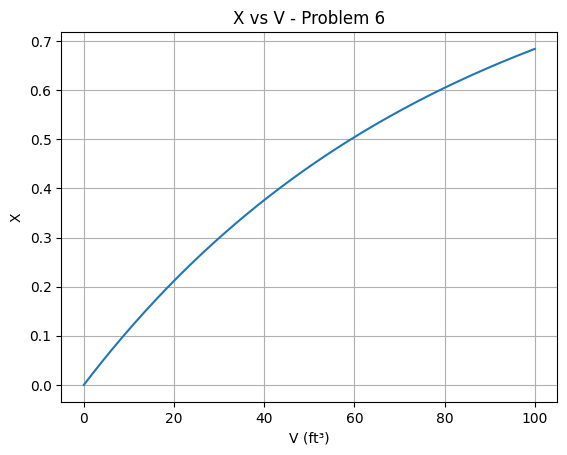

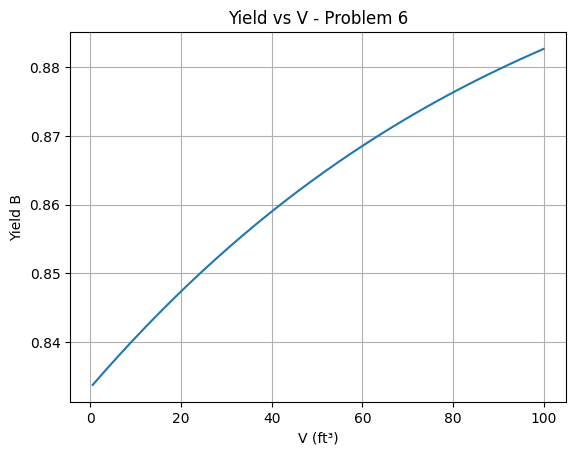

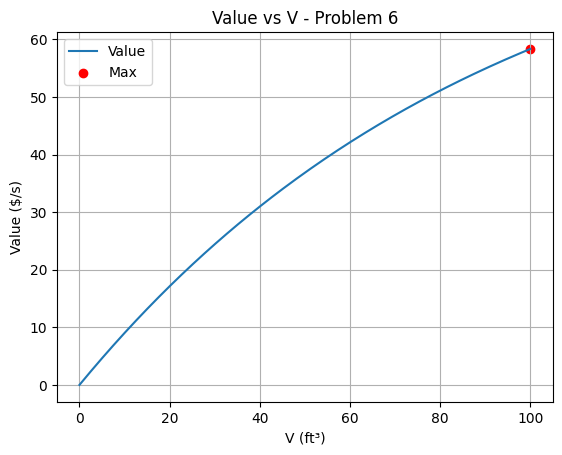

In [13]:
# Problem 6: Optimizing PFR for cost
# Assume main reaction A -> B, k1 CA
# Side reaction 2A -> C, k2 CA^2
# Adjust k1, k2, CA0, FA0 based on problem (example values used)
def dF_dV(F, V, k1, k2, CA0):
    FA, FB, FC = F
    FT = FA + FB + FC
    CA = CA0 * FA / FT
    rA = -k1 * CA - 2 * k2 * CA**2
    rB = k1 * CA
    rC = k2 * CA**2
    return [rA, rB, rC]

k1 = 0.1  # Example, adjust
k2 = 0.01  # Example, adjust
CA0 = 1.0
FA0 = 10.0  # mol/s, example
V_span = np.linspace(0, 100, 200)  # ft³, adjust range

F_soln = odeint(dF_dV, [FA0, 0, 0], V_span, args=(k1, k2, CA0))

FA = F_soln[:, 0]
FB = F_soln[:, 1]
FC = F_soln[:, 2]

X = (FA0 - FA) / FA0
yield_B = FB / (FA0 - FA)  # Instantaneous yield or overall

# Assume value = FB * price_B - FC * cost_C (adjust prices)
price_B = 10  # $/mol, example
cost_C = 5  # $/mol, example
value = FB * price_B - FC * cost_C

max_idx = np.argmax(value)
max_V = V_span[max_idx]
max_value = value[max_idx]

print(f'Max value at V = {max_V:.2f} ft³')

plt.figure()
plt.plot(V_span, X, label='Conversion X')
plt.xlabel('V (ft³)')
plt.ylabel('X')
plt.title('X vs V - Problem 6')
plt.grid(True)
plt.show()

plt.figure()
plt.plot(V_span, yield_B, label='Yield B')
plt.xlabel('V (ft³)')
plt.ylabel('Yield B')
plt.title('Yield vs V - Problem 6')
plt.grid(True)
plt.show()

plt.figure()
plt.plot(V_span, value, label='Value')
plt.scatter(max_V, max_value, color='red', label='Max')
plt.xlabel('V (ft³)')
plt.ylabel('Value ($/s)')
plt.title('Value vs V - Problem 6')
plt.legend()
plt.grid(True)
plt.show()